<a href="https://colab.research.google.com/github/vyshnavivallepu7-code/Machine-learning/blob/main/iris_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Missing Values After Filling:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Correlation Matrix:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865  

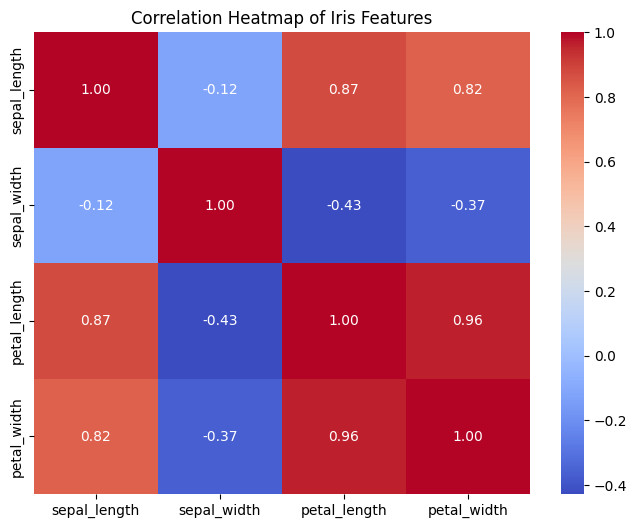

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Iris dataset
df = sns.load_dataset("iris")

print("Original Dataset:")
print(df.head())

# -------------------------------
# 1. DATA CLEANING
# -------------------------------

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values using mean
numeric_columns = df.select_dtypes(include='number').columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
    )

print("\nMissing Values After Filling:")
print(df.isnull().sum())

# -------------------------------
# 2. DATA REDUCTION
# -------------------------------

# Select only numeric features
X = df[numeric_columns]

# Calculate correlation matrix
correlation = X.corr()

print("\nCorrelation Matrix:")
print(correlation)

# Identify highly correlated features
print("\nHighly Correlated Features:")

for i in range(len(correlation.columns)):
        for j in range(i):
                if abs(correlation.iloc[i, j]) > 0.7:
                            print(correlation.columns[i],
                                                            "and",
                                                                            correlation.columns[j],
                                                                                            "->",
                                                                                                            correlation.iloc[i, j]
                                                                                                                        )

# -------------------------------
# 3. HEATMAP
# -------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
              correlation,
                  annot=True,
                      cmap="coolwarm",
                        fmt=".2f"
                    )

plt.title("Correlation Heatmap of Iris Features")
plt.show()